<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/A0_004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

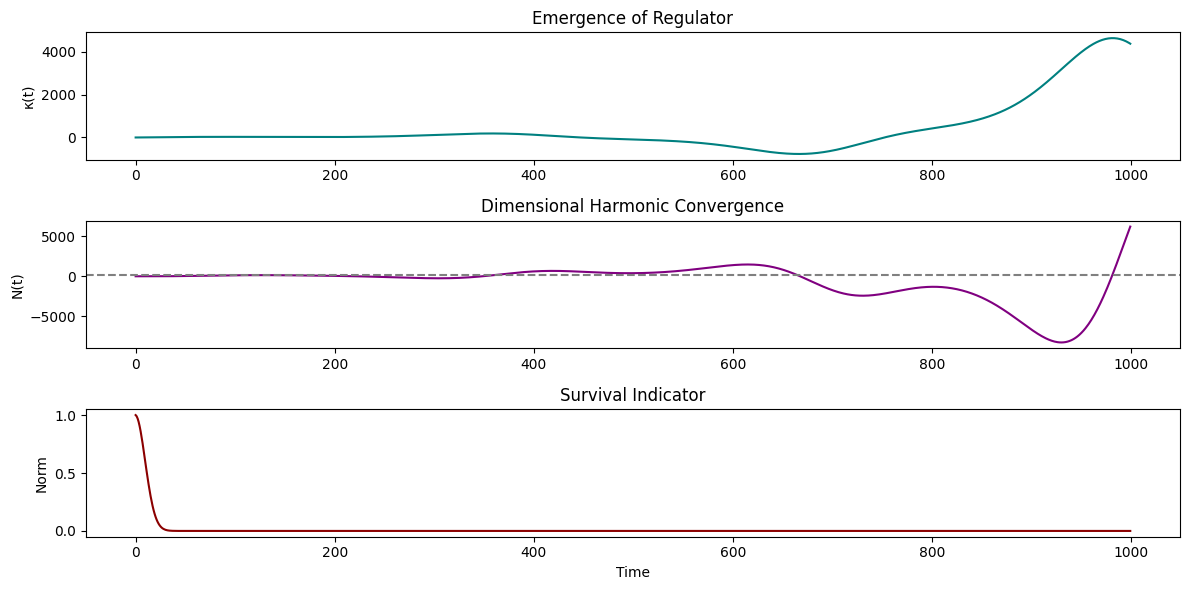

In [1]:
# Act XIV: Maximal Survival Scan with Regulator
import numpy as np
import matplotlib.pyplot as plt

# Parameters
t_max = 1000
dt = 1
time = np.arange(0, t_max, dt)

# Constants
alpha = 0.01   # entropy decay rate
beta = 0.1     # regulator influence
gamma = 0.005  # learning rate
N_target = 100

# Initialize arrays
N = np.zeros_like(time, dtype=float)
kappa = np.zeros_like(time, dtype=float)
norm = np.zeros_like(time, dtype=float)
A = np.sin(time / 50)

# Initial conditions
kappa[0] = 0.001
N[0] = 0
norm[0] = 1.0

# Dynamics
for t in range(1, len(time)):
    dN = -alpha * N[t-1] + beta * kappa[t-1] * A[t-1]
    N[t] = N[t-1] + dN * dt

    dkappa = gamma * (N_target - N[t-1])
    kappa[t] = kappa[t-1] + dkappa * dt

    decay = np.exp(-alpha * t)
    norm[t] = norm[t-1] if abs(N[t] - N_target) < 1 else norm[t-1] * decay

# Plotting
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(time, kappa, label='κ(t)', color='teal')
plt.ylabel('κ(t)')
plt.title('Emergence of Regulator')

plt.subplot(3, 1, 2)
plt.plot(time, N, label='N(t)', color='purple')
plt.axhline(N_target, color='gray', linestyle='--', label='Target N=100')
plt.ylabel('N(t)')
plt.title('Dimensional Harmonic Convergence')

plt.subplot(3, 1, 3)
plt.plot(time, norm, label='Global Norm', color='darkred')
plt.ylabel('Norm')
plt.xlabel('Time')
plt.title('Survival Indicator')

plt.tight_layout()
plt.show()
